# Dataset Temporal Analysis
The question we want to answer here is:  
- **“On what time scale can we meaningfully correlate measurements with spatially adjacent industrial sites and emission sources?”**

    Grouping per year

    Measurement count per year as distinct columns

    heatmap: mearumements per year
  

In [2]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pfas_trace.config import DATASET_FILE

In [3]:
df = pd.read_parquet(DATASET_FILE).query('country=="France"')

## Just how extensive is the time coverage, anyway?

In [4]:
df.category.unique()

<ArrowStringArray>
['Known PFAS user', 'Presumptive', 'Measurement', 'PFAS production facility']
Length: 4, dtype: str

We do have only 25 Known-PFAS-User und 4 PFAS-production-facilities in france. And these records do not contain any pfas-values.

In [5]:
df_sources = (
    df[
        df["category"].isin([
            "Known PFAS user",
            "PFAS production facility",
        ])
    ]
    .groupby(["category", "name"])
    .agg(
        n_records=("name", "size"),
        n_locations=(
            "lat",
            lambda x: x.astype(str).str.cat(
                df.loc[x.index, "lon"].astype(str),
                sep=","
            ).nunique()
        ),
        n_pfas_sum=("pfas_sum", "count"),
        n_pfas_values=(
            "pfas_values",
            lambda x: x.map(
                lambda value: len(ast.literal_eval(value))
                if isinstance(value, str)
                else 0
            ).sum()
        ),
    )
    .reset_index()
    .sort_values(
        ["category", "n_locations"],
        ascending=[True, False]
    )
)

df_sources

,category,name,n_records,n_locations,n_pfas_sum,n_pfas_values
9,Known PFAS user,Fluorotechnique,2,2,0,0
11,Known PFAS user,Freudenberg,2,2,0,0
0,Known PFAS user,3P Performance Plastics Products,1,1,0,0
1,Known PFAS user,Aberflon,1,1,0,0
2,Known PFAS user,Approflon,1,1,0,0
3,Known PFAS user,BASF Agri Solutions,1,1,0,0
4,Known PFAS user,BioEx,1,1,0,0
5,Known PFAS user,C2M Aurochs Industrie,1,1,0,0
6,Known PFAS user,DEMGY SPN,1,1,0,0
7,Known PFAS user,Eau et Feu,1,1,0,0


### Prepare Temporal Data

In [6]:
df_measurements = df[
    df["category"] == "Measurement"
]
df_measurements["date"] = pd.to_datetime(df_measurements["date"], errors="coerce")
df_measurements["year"] = df_measurements["date"].dt.year

In [7]:


# Location identifier
location_columns = ["lat", "lon"]

# Measurements per year
measurements_per_year = (
    df_measurements.dropna(subset=["year"])
    .groupby("year")
    .size()
)

# Distinct locations per year
locations_per_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby("year")[location_columns]
    .apply(lambda x: x.drop_duplicates().shape[0])
)

# Number of years measured per location
years_per_location = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby(location_columns)["year"]
    .nunique()
)

# Measurements per location and year
measurements_location_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby([*location_columns, "year"])
    .size()
    .rename("measurement_count")
    .reset_index()
)

measurement_heatmap = (
    measurements_location_year
    .pivot(
        index=location_columns,
        columns="year",
        values="measurement_count",
    )
    .fillna(0)
)

### Plot Temporal Data

Text(0, 0.5, 'Number of locations')

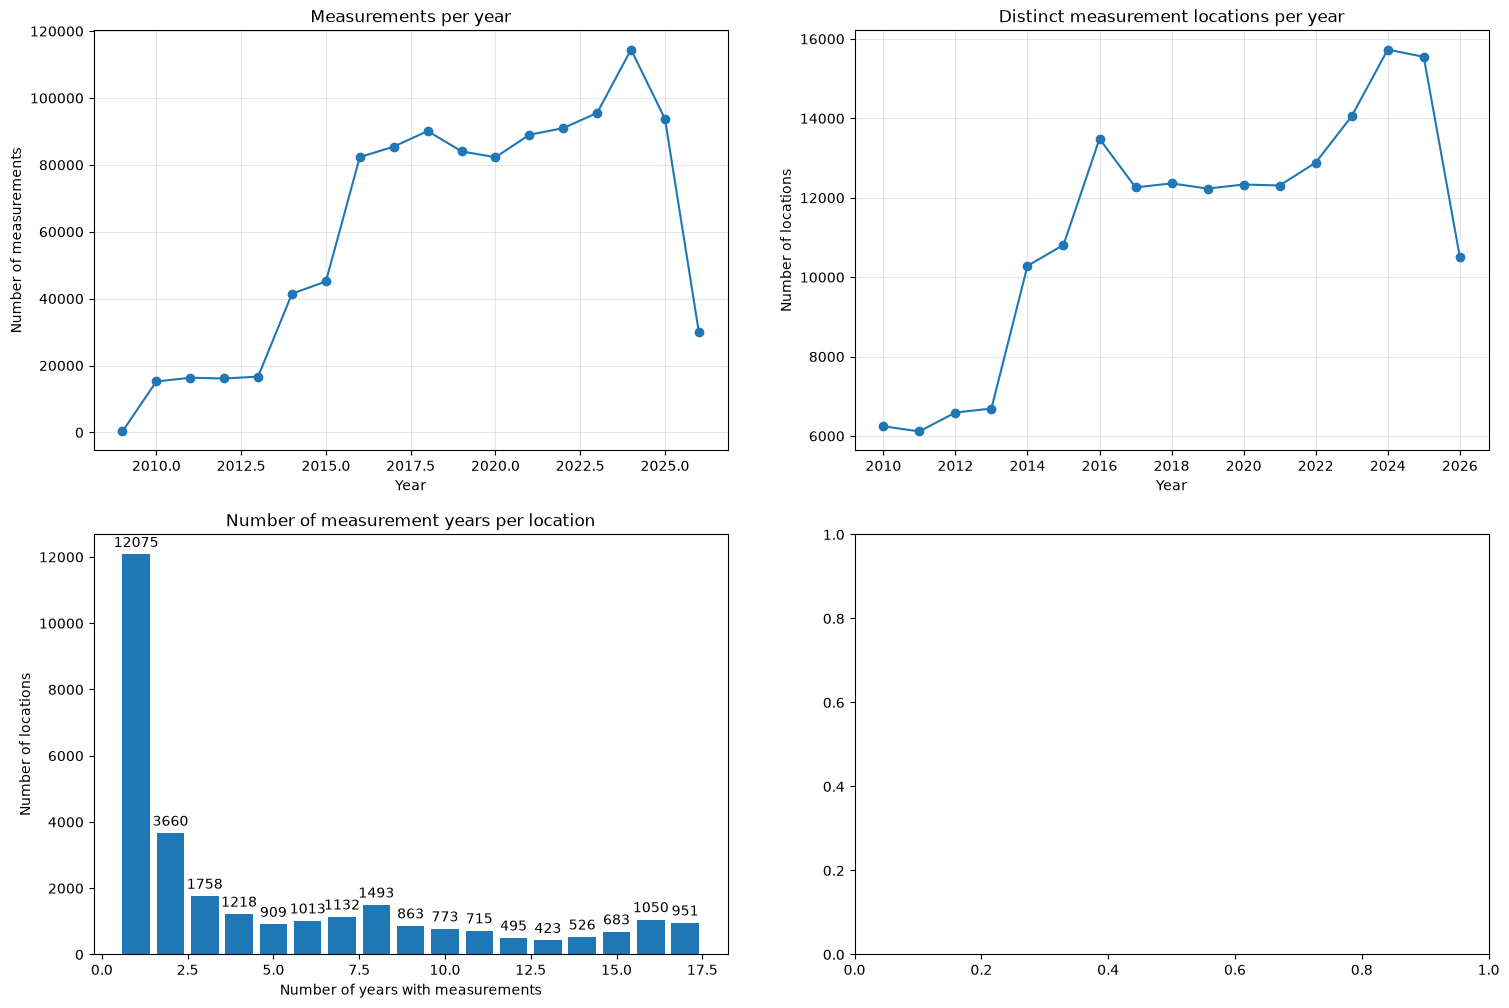

In [21]:

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12),
)

# 1. Measurements per year
axes[0, 0].plot(
    measurements_per_year.index,
    measurements_per_year.values,
    marker="o",
)

axes[0, 0].set_title("Measurements per year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Number of measurements")
axes[0, 0].grid(True, alpha=0.3)


# 2. Distinct locations per year
axes[0, 1].plot(
    locations_per_year.index,
    locations_per_year.values,
    marker="o",
)

axes[0, 1].set_title("Distinct measurement locations per year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Number of locations")
axes[0, 1].grid(True, alpha=0.3)


# 3. Distribution of years measured per location
location_counts = years_per_location.value_counts().sort_index()

axes[1, 0].bar(
    location_counts.index,
    location_counts.values,
    width=0.8,
)

axes[1, 0].bar_label(
    axes[1, 0].containers[0],
    fmt="%d",
    padding=3,
)

axes[1, 0].set_title(
    "Number of measurement years per location"
)
axes[1, 0].set_xlabel("Number of years with measurements")
axes[1, 0].set_ylabel("Number of locations")

There are definitely a lot different locations measured over a long period since 16 years.

In [28]:
years_per_location.sort_values(ascending=False).head(50)

lat        lon        city                    
48.982550   0.424446  La Folletière-Abenon        17
47.951029   3.441254  Champlay                    17
45.543688   3.529875  Échandelys                  17
46.310238   4.886128  Replonges                   17
47.975066   4.674551  Riel-les-Eaux               17
48.979828   1.672697  Buchelay                    17
48.980710   5.126557  Èvres                       17
48.719895   4.029380  Euvy                        17
43.667596   4.061763  Valergues                   17
48.705811  -0.324293  Saint-Hilaire-de-Briouze    17
48.712363   3.488134  Courgivaux                  17
49.238212  -1.314064  Terre-et-Marais             17
49.238351  -0.731394  Arganchy                    17
47.331160   6.300403  Fourbanne                   17
43.677654   4.431216  Saint-Gilles                17
43.693291   4.276099  Vauvert                     17
49.252566  -1.504469  Vesly                       17
43.291316   5.862809  Signes                      17

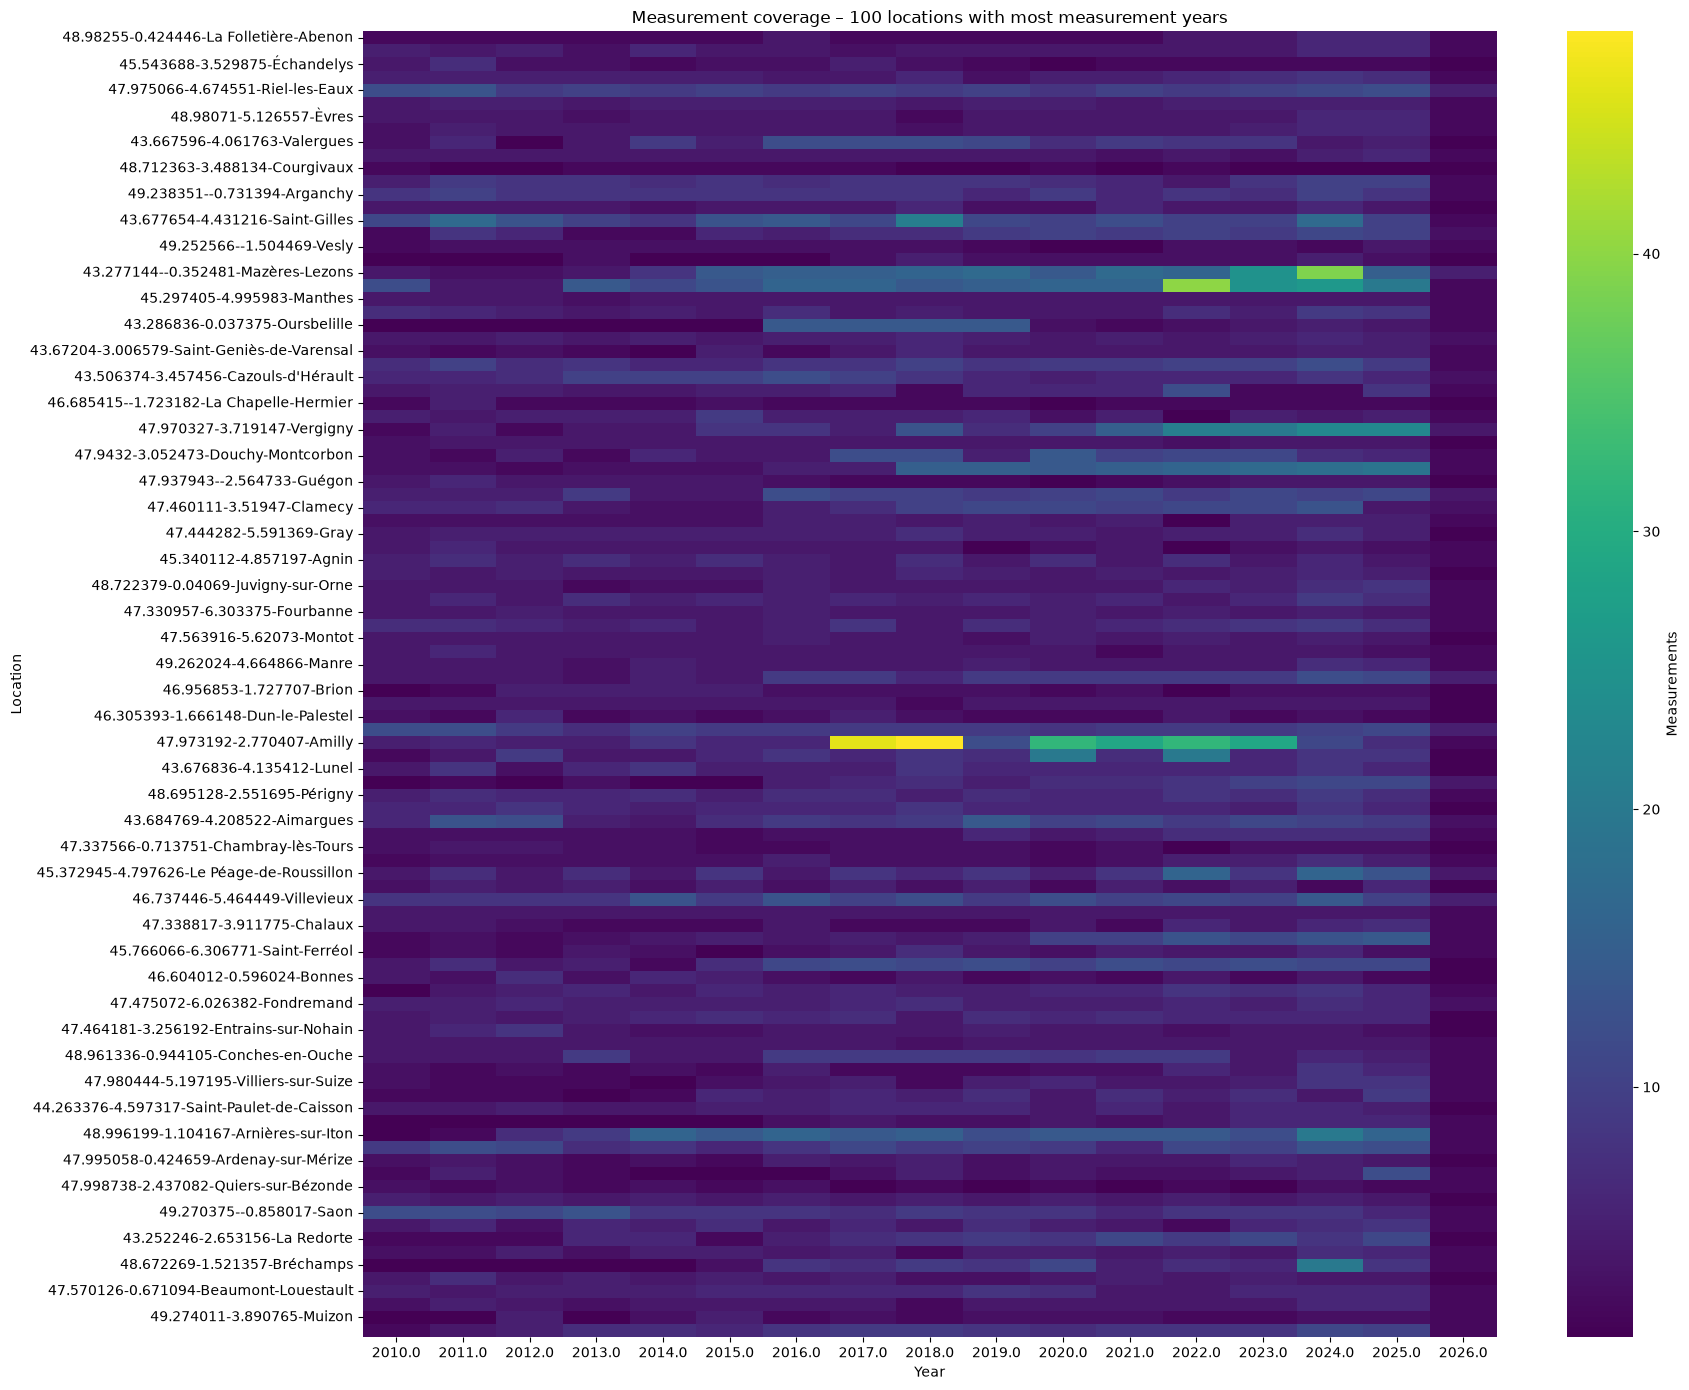

In [11]:
location_columns = ["lat", "lon", "city"]

# Number of years with measurements per location
years_per_location = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby(location_columns)["year"]
    .nunique()
)

# Measurements per location and year
measurements_location_year = (
    df_measurements.dropna(subset=["year", *location_columns])
    .groupby([*location_columns, "year"])
    .size()
    .rename("measurement_count")
    .reset_index()
)

# Create heatmap
measurement_heatmap = (
    measurements_location_year
    .pivot(
        index=location_columns,
        columns="year",
        values="measurement_count",
    )
    .fillna(0)
)

# Sort locations by number of measurement years
location_order = (
    years_per_location
    .sort_values(ascending=False)
    .index
)

measurement_heatmap_sorted = measurement_heatmap.loc[
    location_order
]

# Show top 100 locations
measurement_heatmap_top = measurement_heatmap_sorted.head(100)

plt.figure(figsize=(18, 14))

sns.heatmap(
    measurement_heatmap_top,
    cmap="viridis",
    cbar_kws={"label": "Measurements"},
)

plt.title(
    "Measurement coverage – 100 locations with most measurement years"
)
plt.xlabel("Year")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

## How much overlap is there between locations?

### Closed Industries
Two of 5 producing industries closed 2025

In [38]:
pd.set_option("display.max_colwidth", None)
df.query('category=="PFAS production facility"')["details"]

15236    {"Status": "stopped", "Details": "Closed in 2025 (https://www.leparisien.fr/oise-60/fermeture-de-chemours-la-fin-dune-ere-entre-regrets-et-soulagement-la-ville-a-vecu-a-lombre-de-la-cheminee-06-08-2025-IGDRV5WX3RCTHLUI53NSNCMWJQ.php)", "status last checked": "07/11/2025"}
15237       {"Status": "stopped", "Details": "Closed in 2025 (https://france3-regions.franceinfo.fr/occitanie/gard/ales/pfas-comment-solvay-a-cherche-a-retarder-la-reglementation-du-tfa-qu-il-fabriquait-a-salindres-selon-les-ong-3224063.html)", "status last checked": "07/11/2025"}
15247               {"Status": "producing", "Details": "Still producing (https://www.lemonde.fr/planete/article/2024/10/15/pfas-le-site-daikin-de-pierre-benite-autorise-a-lancer-la-fabrication-d-un-nouveau-produit-perfluore_6352378_3244.html)", "status last checked": "07/11/2025"}
15249                                                                                                                    {"PFAS produced": "PVDF", "Status

In [3]:
df.category.unique()

<ArrowStringArray>
['Known PFAS user', 'Presumptive', 'Measurement', 'PFAS production facility']
Length: 4, dtype: str

### Year Validation

In [11]:
df.query('category=="Presumptive"').head()

,category,lat,lon,name,city,country,type,sector,source_type,data_collection_method,...,source_url,dataset_id,dataset_name,pfas_values,unit,pfas_sum,details,matrix,date,year
231,Presumptive,45.34250,4.79649,TREDI,SALAISE-SUR-SANNE,France,Industrial site,Treatment and disposal of hazardous waste,Authorities,Public data - Download,...,https://industry.eea.europa.eu/#/home,1,EPRTR,[],NaN,NaN,"{""eprtr_activity_code"": ""5(a)"", ""eprtr_sector""...",NaN,NaN,NaN
235,Presumptive,44.06174,5.99984,ARKEMA FRANCE,CHATEAU ARNOUX ST AUBAN,France,Industrial site,Treatment and disposal of hazardous waste,Authorities,Public data - Download,...,https://industry.eea.europa.eu/#/home,1,EPRTR,[],NaN,NaN,"{""eprtr_activity_code"": ""5(a)"", ""eprtr_sector""...",NaN,NaN,NaN
240,Presumptive,49.01830,3.03525,HELIO PRINT,MARY-SUR-MARNE,France,Industrial site,Treatment and coating of metals,Authorities,Public data - Download,...,https://industry.eea.europa.eu/#/home,1,EPRTR,[],NaN,NaN,"{""eprtr_activity_code"": ""2(f)"", ""eprtr_sector""...",NaN,NaN,NaN
241,Presumptive,44.85130,-0.50707,VALBOM,CENON,France,Industrial site,Treatment and disposal of non-hazardous waste,Authorities,Public data - Download,...,https://industry.eea.europa.eu/#/home,1,EPRTR,[],NaN,NaN,"{""eprtr_activity_code"": ""5(b)"", ""eprtr_sector""...",NaN,NaN,NaN
245,Presumptive,45.01000,-0.54000,ORION ENGENEERED CARBONS SAS,AMBES,France,Industrial site,Manufacture of refined petroleum products,Authorities,Public data - Download,...,https://industry.eea.europa.eu/#/home,1,EPRTR,[],NaN,NaN,"{""eprtr_activity_code"": ""1(a)"", ""eprtr_sector""...",NaN,NaN,NaN


In [8]:
df.query('category=="Measurement"').year.value_counts()

year
2024.0    114483
2023.0     95550
2025.0     93751
2022.0     90993
2018.0     90169
2021.0     89007
2017.0     85458
2019.0     84062
2016.0     82335
2020.0     82273
2015.0     45149
2014.0     41488
2026.0     29956
2013.0     16681
2011.0     16352
2012.0     16125
2010.0     15229
2009.0       354
2005.0         8
2008.0         7
2006.0         7
Name: count, dtype: int64

### date-accuracy
Only 5 recors in France do have a date set. All the other measurements are only recorded by "year".

In [6]:
df.query('date.notna()').head()

,category,lat,lon,name,city,country,type,sector,source_type,data_collection_method,...,source_url,dataset_id,dataset_name,pfas_values,unit,pfas_sum,details,matrix,date,year
78399,Measurement,50.885284,1.662663,BSS000AENC,Wissant,France,Sampling location,NaN,Authorities,Public data - API,...,https://ades.eaufrance.fr/,28,france_ades,"[{""cas_id"": ""112281-77-3"", ""unit"": ""ng/l"", ""su...",ng/l,0.0,"{""code_bss"": ""00053X0002/SO1"", ""altitude"": 20.0}",Groundwater,2011-04-27,2011.0
78400,Measurement,50.885284,1.662663,BSS000AENC,Wissant,France,Sampling location,NaN,Authorities,Public data - API,...,https://ades.eaufrance.fr/,28,france_ades,"[{""cas_id"": ""79622-59-6"", ""unit"": ""ng/l"", ""sub...",ng/l,0.0,"{""code_bss"": ""00053X0002/SO1"", ""altitude"": 20.0}",Groundwater,2013-06-07,2013.0
78401,Measurement,50.885284,1.662663,BSS000AENC,Wissant,France,Sampling location,NaN,Authorities,Public data - API,...,https://ades.eaufrance.fr/,28,france_ades,"[{""cas_id"": ""79622-59-6"", ""unit"": ""ng/l"", ""sub...",ng/l,0.0,"{""code_bss"": ""00053X0002/SO1"", ""altitude"": 20.0}",Groundwater,2015-01-23,2015.0
78402,Measurement,50.885284,1.662663,BSS000AENC,Wissant,France,Sampling location,NaN,Authorities,Public data - API,...,https://ades.eaufrance.fr/,28,france_ades,"[{""cas_id"": ""50594-66-6"", ""unit"": ""ng/l"", ""sub...",ng/l,0.0,"{""code_bss"": ""00053X0002/SO1"", ""altitude"": 20.0}",Groundwater,2017-09-12,2017.0
78403,Measurement,50.885284,1.662663,BSS000AENC,Wissant,France,Sampling location,NaN,Authorities,Public data - API,...,https://ades.eaufrance.fr/,28,france_ades,"[{""cas_id"": ""50594-66-6"", ""unit"": ""ng/l"", ""sub...",ng/l,0.0,"{""code_bss"": ""00053X0002/SO1"", ""altitude"": 20.0}",Groundwater,2021-02-23,2021.0


### PFas_sum Verlauf pro Location

In [9]:
# Location identifier
location_columns = ["lat", "lon"]

pfas_location_year = (
    df_measurements
    .dropna(subset=["year", *location_columns, "pfas_sum"])
    .groupby([*location_columns, "year"])["pfas_sum"]
    .median()
    .reset_index()
)

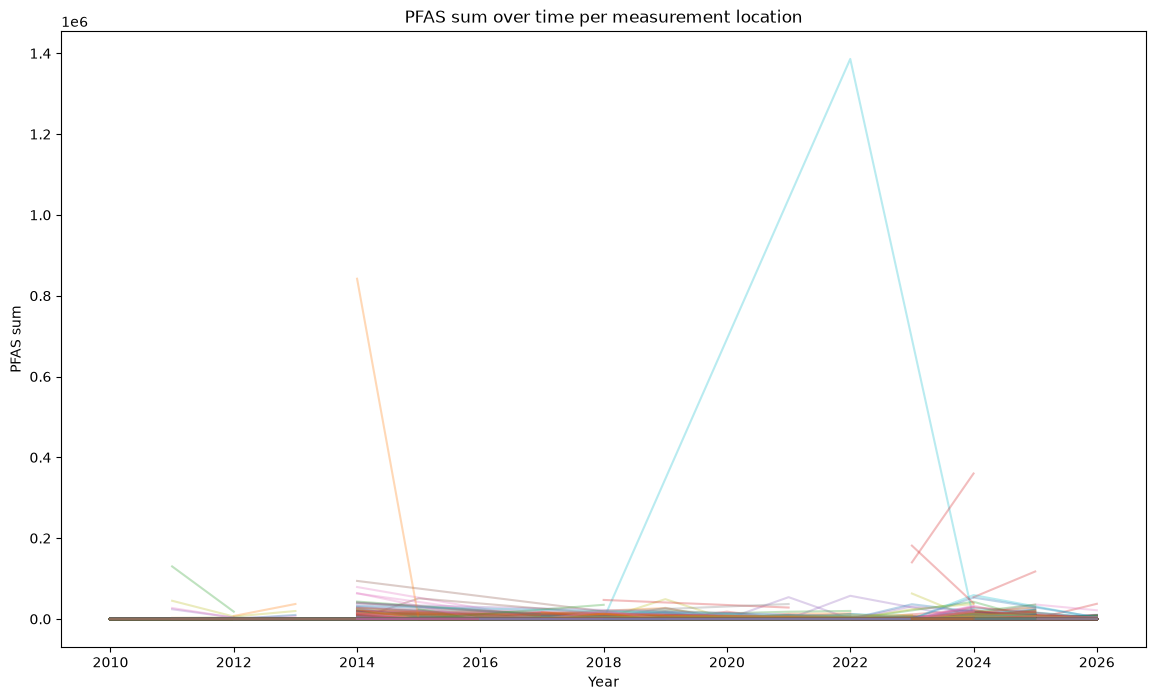

In [10]:
def plot_pfas_location_year(data: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(14, 8))

    for (lat, lon), group in data.groupby(location_columns):
        group = group.sort_values("year")

        ax.plot(
            group["year"],
            group["pfas_sum"],
            alpha=0.3,
        )

    ax.set_xlabel("Year")
    ax.set_ylabel("PFAS sum")
    ax.set_title("PFAS sum over time per measurement location")

    plt.show()

plot_pfas_location_year(pfas_location_year)

In [12]:
# Outlier analysis
df_measurements.nlargest(10, "pfas_sum")[
    [*location_columns,"city","name", "year", "pfas_sum"]
]

,lat,lon,city,name,year,pfas_sum
1290811,43.380003,-0.603006,MOURENX,FINORGA SAS - Rejet2 eaux biodégradables (Aval),2024.0,509000000.0
1316754,49.310362,1.007807,SAINT-AUBIN-LES-ELBEUF,BASF AGRI PRODUCTION SAS - Point ES (eaux sale...,2024.0,420000000.0
1294950,44.171826,4.151853,SALINDRES,SOLVAY Rhodia Opérations - Point de rejet des ...,2023.0,91000000.0
1316616,49.291294,2.507002,VILLERS-SAINT-PAUL,CHEMOURS France - R831 (Aval),2023.0,51000000.0
1290833,43.380003,-0.603006,MOURENX,FINORGA SAS - Rejet2 eaux biodégradables (Aval),2024.0,50000000.0
1316596,49.291294,2.507002,VILLERS-SAINT-PAUL,CHEMOURS France - R831 (Aval),2023.0,49000000.0
1294947,44.171826,4.151853,SALINDRES,SOLVAY Rhodia Opérations - Point de rejet des ...,2023.0,28900000.0
1316685,49.306230,1.007527,SAINT-AUBIN-LES-ELBEUF,EUROAPI FRANCE - Point SR406 (eaux sales) (Aval),2024.0,28000000.0
1316374,49.291294,2.507002,VILLERS-SAINT-PAUL,CHEMOURS France - R831 (Aval),2024.0,26700000.0
1294801,44.169532,4.151732,SALINDRES,GIE CHIMIE SALINDRES - rejets step (Aval),2023.0,17500000.0


In [ ]:
result = df_measurements.query(
    'city == "MOURENX" and name.str.startswith("FINORGA") and year == 2024.0'
)

with pd.option_context("display.max_columns", None):
    display(result)

with pd.option_context("display.max_colwidth",None):
    display(result[["source_url","pfas_values","details", "pfas_sum"]])


,category,lat,lon,name,city,country,type,sector,source_type,data_collection_method,source_text,source_url,dataset_id,dataset_name,pfas_values,unit,pfas_sum,details,matrix,date,year
1290806,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""355-46-4"", ""unit"": ""ng/l"", ""subst...",ng/l,1430.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-07-08,2024.0
1290807,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""1763-23-1"", ""unit"": ""ng/l"", ""subs...",ng/l,12300.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-07-08,2024.0
1290808,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""375-22-4"", ""unit"": ""ng/l"", ""subst...",ng/l,0.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-07-08,2024.0
1290809,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""307-24-4"", ""unit"": ""ng/l"", ""subst...",ng/l,260.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-12-10,2024.0
1290810,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""2706-90-3"", ""unit"": ""ng/l"", ""subs...",ng/l,420.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-12-10,2024.0
1290811,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""76-05-1"", ""unit"": ""ng/l"", ""substa...",ng/l,509000000.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-12-10,2024.0
1290812,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""355-46-4"", ""unit"": ""ng/l"", ""subst...",ng/l,0.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-12-10,2024.0
1290813,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""375-92-8"", ""unit"": ""ng/l"", ""subst...",ng/l,750.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-06-11,2024.0
1290814,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authorities,Public data - Download,DREAL Nouvelle-Aquitaine,https://www.nouvelle-aquitaine.developpement-d...,142,France - ICPE,"[{""cas_id"": ""335-67-1"", ""unit"": ""ng/l"", ""subst...",ng/l,6000.0,"{""url_fiche"": ""https://www.georisques.gouv.fr/...",Wastewater,2024-06-11,2024.0
1290815,Measurement,43.380003,-0.603006,FINORGA SAS - Rejet2 eaux biodégradables (Aval),MOURENX,France,Sampling location,NaN,Authori

,source_url,pfas_values,details,pfas_sum
1290806,https://www.nouvelle-aquitaine.developpement-durable.gouv.fr/pfas-a14914.html?lang=fr,"[{""cas_id"": ""355-46-4"", ""unit"": ""ng/l"", ""substance"": ""PFHxS"", ""value"": 1430.0}]","{""url_fiche"": ""https://www.georisques.gouv.fr/risques/installations/donnees/details/0005202718"", ""id"": 5202718.0, ""Flux massique (g/j)"": 0.0243, ""R\u00e9gion"": ""Nouvelle-Aquitaine"", ""Code postal"": 64150, ""Vol.Moy.J."": ""17.0 m3/j"", ""AOF"": ""10700000.0 \u00b5g/L"", ""activite"": ""Industrie pharmaceutique"", ""original_matrix (Origine / Destination des eaux)"": ""raccord\u00e9 \u00e0 une station d'\u00e9puration interne""}",1430.0
1290807,https://www.nouvelle-aquitaine.developpement-durable.gouv.fr/pfas-a14914.html?lang=fr,"[{""cas_id"": ""1763-23-1"", ""unit"": ""ng/l"", ""substance"": ""PFOS"", ""value"": 12300.0}]","{""url_fiche"": ""https://www.georisques.gouv.fr/risques/installations/donnees/details/0005202718"", ""id"": 5202718.0, ""Flux massique (g/j)"": 0.2091, ""R\u00e9gion"": ""Nouvelle-Aquitaine"", ""Code postal"": 64150, ""Vol.Moy.J."": ""17.0 m3/j"", ""AOF"": ""10700000.0 \u00b5g/L"", ""activite"": ""Industrie pharmaceutique"", ""original_matrix (Origine / Destination des eaux)"": ""raccord\u00e9 \u00e0 une station d'\u00e9puration interne""}",12300.0
1290808,https://www.nouvelle-aquitaine.developpement-durable.gouv.fr/pfas-a14914.html?lang=fr,"[{""cas_id"": ""375-22-4"", ""unit"": ""ng/l"", ""substance"": ""PFBA"", ""less_than"": 500.0}, {""cas_id"": ""2706-90-3"", ""unit"": ""ng/l"", ""substance"": ""PFPeA"", ""less_than"": 500.0}, {""cas_id"": ""307-24-4"", ""unit"": ""ng/l"", ""substance"": ""PFHxA"", ""less_than"": 500.0}, {""cas_id"": ""375-85-9"", ""unit"": ""ng/l"", ""substance"": ""PFHpA"", ""less_than"": 500.0}, {""cas_id"": ""335-67-1"", ""unit"": ""ng/l"", ""substance"": ""PFOA"", ""less_than"": 500.0}, {""cas_id"": ""375-95-1"", ""unit"": ""ng/l"", ""substance"": ""PFNA"", ""less_than"": 500.0}, {""cas_id"": ""335-76-2"", ""unit"": ""ng/l"", ""substance"": ""PFDA"", ""less_than"": 500.0}, {""cas_id"": ""2058-94-8"", ""unit"": ""ng/l"", ""substance"": ""PFU(n)DA"", ""less_than"": 500.0}, {""cas_id"": ""307-55-1"", ""unit"": ""ng/l"", ""substance"": ""PFDoDA"", ""less_than"": 500.0}, {""cas_id"": ""72629-94-8"", ""unit"": ""ng/l"", ""substance"": ""PFTrDA"", ""less_than"": 500.0}, {""cas_id"": ""375-73-5"", ""unit"": ""ng/l"", ""substance"": ""PFBS"", ""less_than"": 500.0}, {""cas_id"": ""2706-91-4"", ""unit"": ""ng/l"", ""substance"": ""PFPeS"", ""less_than"": 500.0}, {""cas_id"": ""375-92-8"", ""unit"": ""ng/l"", ""substance"": ""1-Heptanesulfonic acid, pentadecafluoro- (6CI)"", ""less_than"": 500.0}, {""cas_id"": ""68259-12-1"", ""unit"": ""ng/l"", ""substance"": ""PFNS"", ""less_than"": 500.0}, {""cas_id"": ""335-77-3"", ""unit"": ""ng/l"", ""substance"": ""PFDS"", ""less_than"": 500.0}, {""cas_id"": ""749786-16-1"", ""unit"": ""ng/l"", ""substance"": ""PFUnDS"", ""less_than"": 500.0}, {""cas_id"": ""79780-39-5"", ""unit"": ""ng/l"", ""substance"": ""PFDoS"", ""less_than"": 500.0}, {""cas_id"": ""791563-89-8"", ""unit"": ""ng/l"", ""substance"": ""PFTrS"", ""less_than"": 500.0}]","{""url_fiche"": ""https://www.georisques.gouv.fr/risques/installations/donnees/details/0005202718"", ""id"": 5202718.0, ""R\u00e9gion"": ""Nouvelle-Aquitaine"", ""Code postal"": 64150, ""Vol.Moy.J."": ""17.0 m3/j"", ""AOF"": ""10700000.0 \u00b5g/L"", ""activite"": ""Industrie pharmaceutique"", ""original_matrix (Origine / Destination des eaux)"": ""raccord\u00e9 \u00e0 une station d'\u00e9puration interne""}",0.0
1290809,https://www.nouvelle-aquitaine.developpement-durable.gouv.fr/pfas-a14914.html?lang=fr,"[{""cas_id"": ""307-24-4"", ""unit"": ""ng/l"", ""substance"": ""PFHxA"", ""value"": 260.0}]","{""url_fiche"": ""https://www.georisques.gouv.fr/risques/installations/donnees/details/0005202718"", ""id"": 5202718.0, ""Flux massique (g/j)"": 0.0046, ""R\u00e9gion"": ""Nouvelle-

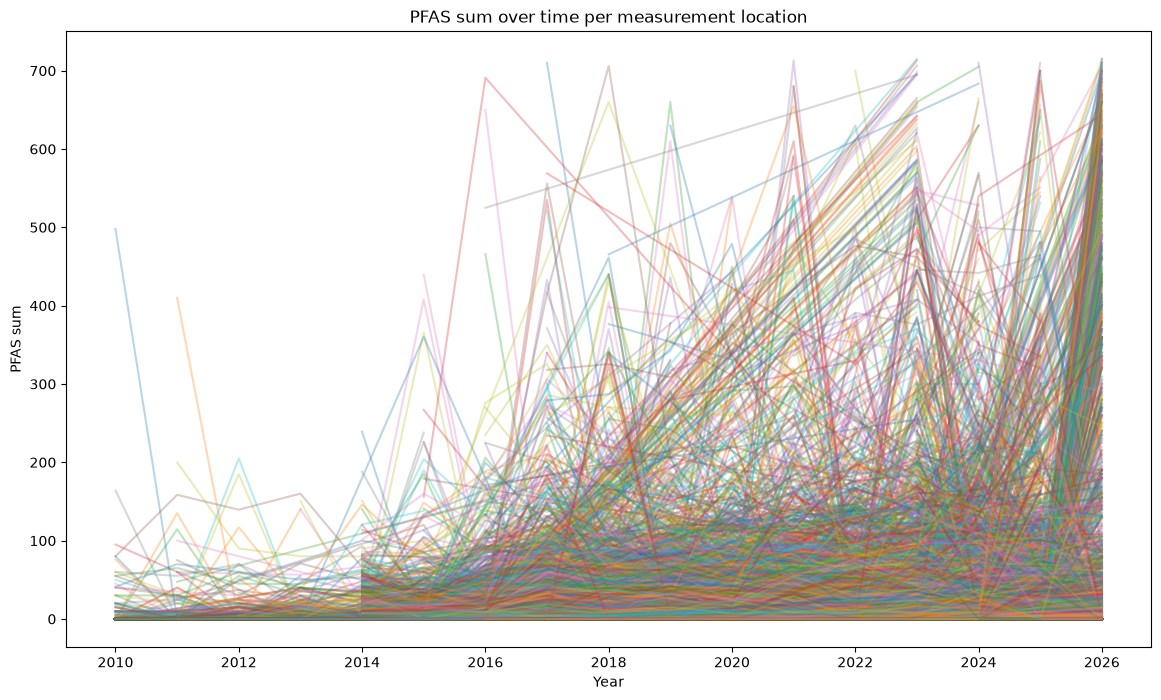

In [11]:
#cut off the upper quartile
plot_data = pfas_location_year[
    pfas_location_year["pfas_sum"] <= pfas_location_year["pfas_sum"].quantile(0.99)
]

plot_pfas_location_year(plot_data)

### Normalized pfas_sum


In [21]:
location_variation = (
    pfas_location_year
    .groupby(location_columns)["pfas_sum"]
    .agg(
        n_years="count",
        median="median",
        mean="mean",
        min="min",
        max="max",
        std="std",
    )
)

location_variation["relative_range"] = np.nan

valid = location_variation["median"] > 0

location_variation.loc[valid, "relative_range"] = (
    (
        location_variation.loc[valid, "max"]
        - location_variation.loc[valid, "min"]
    )
    / location_variation.loc[valid, "median"]
)

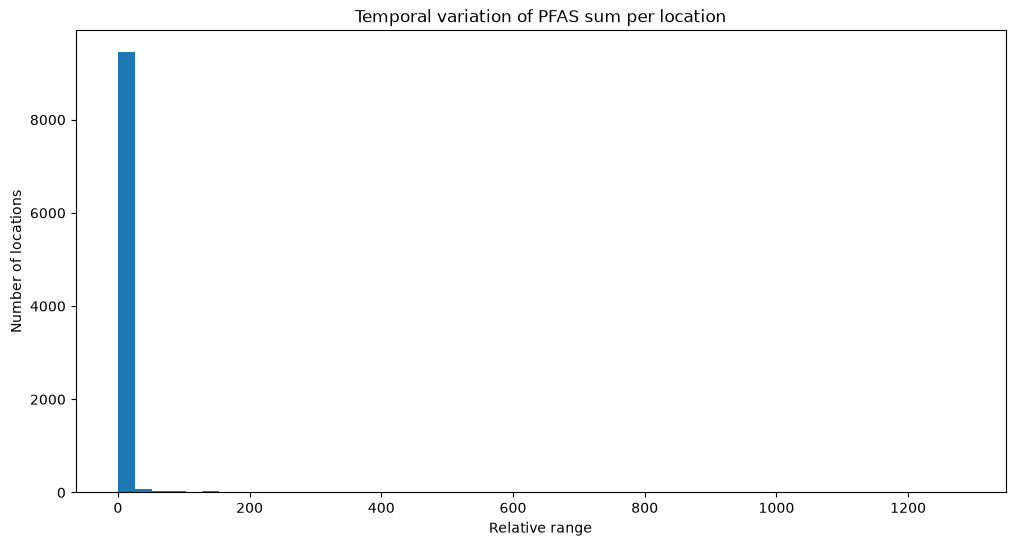

In [22]:
plot_data = location_variation["relative_range"].dropna()

upper_limit = plot_data.quantile(0.99)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    plot_data[plot_data <= upper_limit],
    bins=50,
)

ax.set_xlabel("Relative range")
ax.set_ylabel("Number of locations")
ax.set_title(
    "Temporal variation of PFAS sum per location"
)

plt.show()

## Conclusion
- We do need the other categories without any pfas-values or pfas-sums
- All Measurements have a "date" set

- PFAS production facilities: 5 relevant facilities, of which 3 are still active and 2 will be closed by 2025.
- No information is available regarding when operations began.
- Measurements: almost always reported only by year; only 5 measurements have an exact date.
- This means that, for the measurements, “year” is in fact the highest reliable temporal resolution available.
- The dataset supports annual temporal resolution for measurements. Industrial facilities only provide a coarse activity status, with no information about their start dates. Therefore, temporal matching can exclude measurements occurring after a known facility closure, but cannot reliably establish whether a facility was already operating at the time of earlier measurements.

# Recommendation
8
**Dynamic Features**  
Calculate for each Measurement-Location and Presumtive-Location an additional Feature with:

| Feature                    | Bedeutung                           |
| -------------------------- | ----------------------------------- |
| `producer_distance_min`    | Entfernung zum nächsten Producer    |
| `producer_count_1km`       | Producer innerhalb 1 km             |
| `producer_count_5km`       | Producer innerhalb 5 km             |
| `user_distance_min`        | Entfernung zum nächsten PFAS User   |
| `user_count_1km`           | User innerhalb 1 km                 |
| `presumptive_distance_min` | Entfernung zum nächsten Presumptive |
| `presumptive_count_5km`    | Presumptive innerhalb 5 km          |

The temporal aspects are intentionally ignored because we dont have information about any datapoint from when on until when the chemicals were exposed there. Even a measurement-date and also producers do not unveil this. Therefore we strongly focus on spatial aspects what might discover interesting patterns too.

**Purpose**:  
Are presumptive/producing/using locations actually concentrated in the same areas where many measurements take place?